In [1]:
import numpy as np
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline,splrep, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from IPython.display import display, Math, Latex, Markdown
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets as widgets
import empymod
import discretize
import  os
import glob
import json
import pandas as pd



In [2]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jacobian
eps = torch.finfo(torch.float32).eps
print(eps)

1.1920928955078125e-07


In [3]:
from masa_utils import sci_latex
from masa_utils import InducedPolarizationSimulation
from masa_utils import Pelton_res_f, DDR_f, DDC_f
 

In [4]:
plt.style.use('00_figures.mplstyle')
textwidth = 5.0

In [5]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


In [6]:
rho0= 0.3
res_ref = 0.3
eta= 0.5
expc= 0.6

tau_rho = 1.0e-2

param_text = r"$\rho_0$" + f": {rho0: .2f}, " + r"$\eta$" +f": {eta: .2f}, "  
param_text += r"$\tau_\rho$"+ f": ${fmt(tau_rho, prec=1)}$, " +r"$C$" + f": {expc: .2f}"
mvec_true = np.array([np.log(rho0), eta, np.log(tau_rho), expc])

In [7]:
param_text

'$\\rho_0$:  0.30, $\\eta$:  0.50, $\\tau_\\rho$: $1.0\\cdot 10^{-2}$, $C$:  0.60'

In [8]:
freq_start_log = -1
freq_end_log = 4
freq_step_log = 0.1
nfreq= int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq_1 = np.logspace(freq_start_log, freq_end_log, nfreq)

freq_start_log = 1
freq_end_log = 3
nfreq = int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq_2 = np.logspace(freq_start_log, freq_end_log, nfreq)


In [9]:
IP_model = Pelton_res_f(freq=freq_1)
sim_1 = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
dobs_1 = np.abs(sim_1.ip_model.f(mvec_true))
sim_1.ip_model.store_parameters(mvec_true)
tau_rho, tau_psi, tau_con = sim_1.ip_model.tau_rho, sim_1.ip_model.tau_psi, sim_1.ip_model.tau_con
IP_model = Pelton_res_f(freq=freq_2)
sim_2 = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
dobs_2 = np.abs(sim_2.ip_model.f(mvec_true))


In [10]:
texts = [
    r"$| \rho(\min(f_{\mathrm{band} 1}))|$",
    r"$| \rho(\max(f_{\mathrm{band} 1})) |$",
    r"$| \rho(\min(f_{\mathrm{band} 2})) |$",
    r"$| \rho(\max(f_{\mathrm{band} 2})) |$",
]

texts_xy = []

texts_xy.append(np.r_[freq_1[0], np.abs(dobs_1[0])])
texts_xy.append(np.r_[freq_1[-1], np.abs(dobs_1[-1])])
texts_xy.append(np.r_[freq_2[0], np.abs(dobs_2[0])])
texts_xy.append(np.r_[freq_2[-1], np.abs(dobs_2[-1])])

In [11]:
plt.style.use('00_figures.mplstyle')

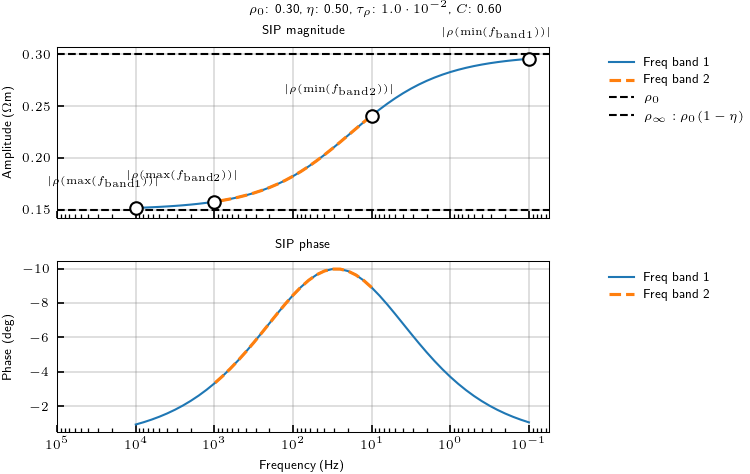

In [12]:
fig, ax = plt.subplots(2, 1, sharex=True,  figsize=(textwidth,3.0))
label = 'Freq band 1'
ax = sim_1.plot_sip_model(mvec_true, ax=ax,
    color='C0', 
    label= label
    )
label = 'Freq band 2'

ax = sim_2.plot_sip_model(mvec_true, ax=ax,
    color='C1', linestyle='--',linewidth=1.5,  
    label=label
    )

ax[0].axhline(y=rho0, color='k', linestyle='--', label=r"$\rho_0$")
ax[0].axhline(y=rho0*(1-eta), color='k', linestyle='--', label=r"$\rho_{\infty}: \rho_0(1-\eta)$ ")
# ax[1].axvline(x=1/2/np.pi/tau_con, color='k', linestyle=':', label=r"$1/2/\pi/\tau_\sigma$")   
# ax[1].axvline(x=1/2/np.pi/tau_psi, color='k', linestyle='-.', label=r"$1/2/\pi/\tau_\phi$")
# ax[1].axvline(x=1/2/np.pi/tau_rho, color='k', linestyle='--' , label=r"$1/2/\pi/\tau_\rho$")

for i, s in enumerate(texts):
    x, y = texts_xy[i]

    # marker at the point
    ax[0].plot(
        x, y,
        marker="o",
        markersize=6,
        markeredgecolor="k",
        markerfacecolor="white",
        zorder=5,
    )

    # annotation
    ax[0].annotate(
        s,
        xy=(x, y),
        xycoords="data",
        textcoords="offset points",
        xytext=(-15, 10),
        ha="center",
        va="bottom",
        fontsize=5,
    )


ax[1].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(left=1.e5)
ax[0].tick_params(labelbottom=False)
ax[0].set_xlabel("")
for a in ax:
    a.legend(loc="upper left", bbox_to_anchor=(1.1,1))
    
ax[0].set_title(fr"SIP magnitude")
ax[1].set_title(fr'SIP phase')
fig.suptitle(
    param_text,
    y=1.05
)

plt.savefig("../manuscript/figures/10_SIP_band12.pdf")
plt.savefig('../figures/10_SIP_band12.png')